In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [9]:
file = "NEPSE_Project_Datasets.xlsx"
excel_file = pd.ExcelFile(file)
excel_file.sheet_names

['README',
 'Stock_Universe',
 'Inflation',
 'NABIL_Sample',
 'Data_Sources',
 'Anaconda_Guide']

In [11]:
stocks = pd.read_excel(
    file,
    sheet_name="Stock_Universe"
)
stocks

,symbol,company_name,sector,source_url,Unnamed: 4,Note,Meaning
0,NABIL,Nabil Bank Limited,Commercial Bank,https://raw.githubusercontent.com/binayabaral/...,NaN,source_url,Direct CSV link for the company's full daily N...
1,EBL,Everest Bank Limited,Commercial Bank,https://raw.githubusercontent.com/binayabaral/...,NaN,Use in Anaconda,pd.read_csv(source_url)
2,CHCL,Chilime Hydropower Company Limited,Hydropower,https://raw.githubusercontent.com/binayabaral/...,NaN,Date filter,2022-01-01 through 2026-12-31
3,NLIC,Nepal Life Insurance Company Limited,Life Insurance,https://raw.githubusercontent.com/binayabaral/...,NaN,NaN,NaN
4,SHIVM,Shivam Cements Limited,Manufacturing and Processing,https://raw.githubusercontent.com/binayabaral/...,NaN,NaN,NaN
5,SHL,Soaltee Hotel Limited,Hotel and Tourism,https://raw.githubusercontent.com/binayabaral/...,NaN,NaN,NaN


In [15]:
nabil_url = stocks.loc[
    stocks["symbol"] == "NABIL",
    "source_url"
].iloc[0]
nabil = pd.read_csv(nabil_url)
nabil.head()

,published_date,open,high,low,close,per_change,traded_quantity,traded_amount,status
0,2011-05-15,1091.0,1155.0,1112.0,1155.0,NaN,38.0,43057.0,A
1,2011-05-16,1155.0,1193.0,1160.0,1193.0,3.29,156.0,183026.0,A
2,2011-05-18,1193.0,1172.0,1150.0,1172.0,-1.76,939.0,1087972.0,A
3,2011-05-19,1172.0,1194.0,1155.0,1194.0,1.88,490.0,573992.0,A
4,2011-05-22,1194.0,1193.0,1178.0,1178.0,-1.34,115.0,135930.0,A


In [17]:
nabil.columns

Index(['published_date', 'open', 'high', 'low', 'close', 'per_change',
       'traded_quantity', 'traded_amount', 'status'],
      dtype='object')

In [19]:
nabil.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3508 entries, 0 to 3507
Data columns (total 9 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   published_date   3508 non-null   object 
 1   open             3508 non-null   float64
 2   high             3508 non-null   float64
 3   low              3508 non-null   float64
 4   close            3508 non-null   float64
 5   per_change       3507 non-null   float64
 6   traded_quantity  3508 non-null   float64
 7   traded_amount    3508 non-null   float64
 8   status           3508 non-null   object 
dtypes: float64(7), object(2)
memory usage: 246.8+ KB


In [21]:
nabil.describe()

,open,high,low,close,per_change,traded_quantity,traded_amount
count,3508.000000,3508.000000,3508.000000,3508.000000,3507.000000,3508.000000,3.508000e+03
mean,1194.836685,1207.462429,1180.114763,1193.685436,0.026136,35663.761973,3.211877e+07
std,595.890081,603.818739,589.933142,597.680441,2.111356,53543.436944,5.820973e+07
min,421.100000,425.000000,419.000000,422.000000,-26.930000,24.000000,2.164600e+04
25%,713.000000,719.750000,706.750000,712.000000,-0.740000,2992.250000,4.484918e+06
50%,1000.000000,1010.000000,993.500000,1000.000000,-0.060000,10590.000000,1.365637e+07
75%,1658.500000,1683.250000,1635.500000,1658.000000,0.625000,51283.250000,3.360470e+07
max,2720.000000,2800.000000,2700.000000,2750.000000,20.870000,705430.000000,1.179786e+09


In [23]:
nabil["published_date"] = pd.to_datetime(
    nabil["published_date"]
)

In [25]:
nabil.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3508 entries, 0 to 3507
Data columns (total 9 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   published_date   3508 non-null   datetime64[ns]
 1   open             3508 non-null   float64       
 2   high             3508 non-null   float64       
 3   low              3508 non-null   float64       
 4   close            3508 non-null   float64       
 5   per_change       3507 non-null   float64       
 6   traded_quantity  3508 non-null   float64       
 7   traded_amount    3508 non-null   float64       
 8   status           3508 non-null   object        
dtypes: datetime64[ns](1), float64(7), object(1)
memory usage: 246.8+ KB


In [27]:
nabil = nabil[
    (nabil["published_date"] >= "2022-01-01") &
    (nabil["published_date"] <= "2026-12-31")
].copy()

In [29]:
print("First date:", nabil["published_date"].min())
print("Last date:", nabil["published_date"].max())

First date: 2022-01-02 00:00:00
Last date: 2026-10-01 00:00:00


In [31]:
nabil = nabil.sort_values(
    "published_date"
).reset_index(drop=True)

In [33]:
nabil.head()

,published_date,open,high,low,close,per_change,traded_quantity,traded_amount,status
0,2022-01-02,1107.0,1151.5,1086.0,1144.0,5.41,263845.0,297049298.9,A
1,2022-01-03,1150.0,1160.0,1137.0,1137.0,-0.61,130041.0,149363282.6,A
2,2022-01-04,1137.0,1139.0,1117.2,1119.0,-1.58,116739.0,130969035.9,A
3,2022-01-05,1122.0,1138.0,1110.0,1111.9,-0.63,75462.0,84317711.8,A
4,2022-01-06,1111.0,1123.0,1099.6,1114.0,0.19,67780.0,75380074.6,A


In [35]:
nabil = nabil[
    [
        "published_date",
        "open",
        "high",
        "low",
        "close",
        "traded_quantity",
        "traded_amount"
    ]
]

In [37]:
nabil.head()

,published_date,open,high,low,close,traded_quantity,traded_amount
0,2022-01-02,1107.0,1151.5,1086.0,1144.0,263845.0,297049298.9
1,2022-01-03,1150.0,1160.0,1137.0,1137.0,130041.0,149363282.6
2,2022-01-04,1137.0,1139.0,1117.2,1119.0,116739.0,130969035.9
3,2022-01-05,1122.0,1138.0,1110.0,1111.9,75462.0,84317711.8
4,2022-01-06,1111.0,1123.0,1099.6,1114.0,67780.0,75380074.6


In [39]:
nabil.isnull().sum()

published_date     0
open               0
high               0
low                0
close              0
traded_quantity    0
traded_amount      0
dtype: int64

In [41]:
nabil["daily_return"] = (
    nabil["close"].pct_change()
)

In [43]:
nabil[
    [
        "published_date",
        "close",
        "daily_return"
    ]
].head(10)

,published_date,close,daily_return
0,2022-01-02,1144.0,NaN
1,2022-01-03,1137.0,-0.006119
2,2022-01-04,1119.0,-0.015831
3,2022-01-05,1111.9,-0.006345
4,2022-01-06,1114.0,0.001889
5,2022-01-09,1113.0,-0.000898
6,2022-01-10,1111.3,-0.001527
7,2022-01-11,1114.8,0.003149
8,2022-01-12,1107.0,-0.006997
9,2022-01-13,1110.0,0.002710


In [45]:
nabil["daily_return_percent"] = (
    nabil["daily_return"] * 100
)

In [47]:
nabil[
    [
        "published_date",
        "close",
        "daily_return_percent"
    ]
].head(10)

,published_date,close,daily_return_percent
0,2022-01-02,1144.0,NaN
1,2022-01-03,1137.0,-0.611888
2,2022-01-04,1119.0,-1.583113
3,2022-01-05,1111.9,-0.634495
4,2022-01-06,1114.0,0.188866
5,2022-01-09,1113.0,-0.089767
6,2022-01-10,1111.3,-0.152740
7,2022-01-11,1114.8,0.314946
8,2022-01-12,1107.0,-0.699677
9,2022-01-13,1110.0,0.271003


In [49]:
first_price = nabil["close"].iloc[0]
last_price = nabil["close"].iloc[-1]

print("First Price:", first_price)
print("Last Price:", last_price)

First Price: 1144.0
Last Price: 528.5


In [51]:
total_return = (
    (last_price - first_price)
    / first_price
) * 100

print(
    "NABIL Total Return:",
    round(total_return, 2),
    "%"
)

NABIL Total Return: -53.8 %


In [53]:
daily_volatility = nabil["daily_return"].std()

annual_volatility = (
    daily_volatility
    * np.sqrt(252)
    * 100
)

print(
    "NABIL Annualized Volatility:",
    round(annual_volatility, 2),
    "%"
)

NABIL Annualized Volatility: 22.4 %


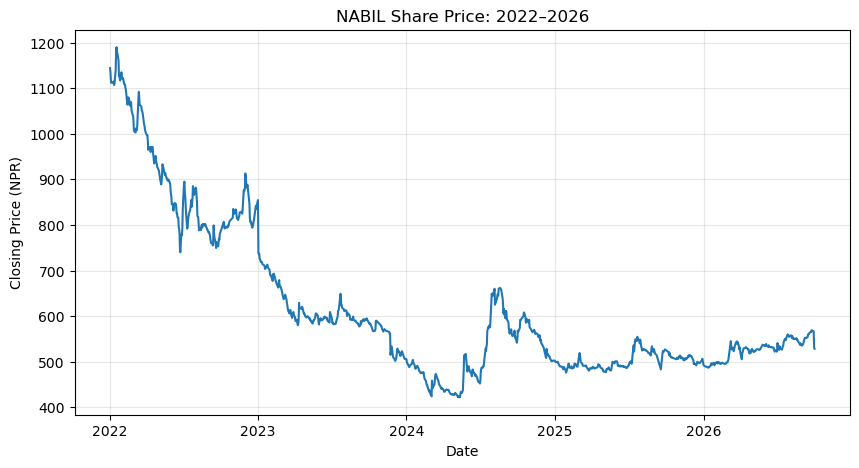

In [55]:
plt.figure(figsize=(10, 5))

plt.plot(
    nabil["published_date"],
    nabil["close"]
)

plt.title("NABIL Share Price: 2022–2026")
plt.xlabel("Date")
plt.ylabel("Closing Price (NPR)")

plt.grid(True, alpha=0.3)

plt.show()

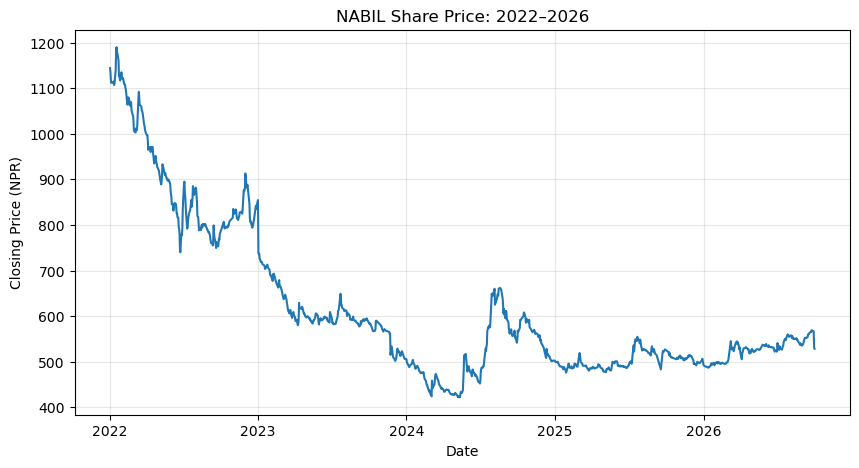

In [57]:
plt.figure(figsize=(10, 5))

plt.plot(
    nabil["published_date"],
    nabil["close"]
)

plt.title("NABIL Share Price: 2022–2026")
plt.xlabel("Date")
plt.ylabel("Closing Price (NPR)")

plt.grid(True, alpha=0.3)

plt.savefig(
    "charts/nabil_price.png",
    bbox_inches="tight"
)

plt.show()

In [59]:
def prepare_stock(symbol):
    
    # Find the data URL from our stock list
    url = stocks.loc[
        stocks["symbol"] == symbol,
        "source_url"
    ].iloc[0]
    
    # Load the raw CSV
    df = pd.read_csv(url)
    
    # Convert the date column
    df["published_date"] = pd.to_datetime(
        df["published_date"]
    )
    
    # Keep only 2022–2026
    df = df[
        (df["published_date"] >= "2022-01-01") &
        (df["published_date"] <= "2026-12-31")
    ].copy()
    
    # Sort oldest to newest
    df = df.sort_values(
        "published_date"
    ).reset_index(drop=True)
    
    # Keep the columns we need
    df = df[
        [
            "published_date",
            "open",
            "high",
            "low",
            "close",
            "traded_quantity",
            "traded_amount"
        ]
    ]
    
    # Calculate daily returns
    df["daily_return"] = (
        df["close"].pct_change()
    )
    
    df["daily_return_percent"] = (
        df["daily_return"] * 100
    )
    
    # Add stock symbol
    df["symbol"] = symbol
    
    return df

In [61]:
ebl = prepare_stock("EBL")
ebl.head()

,published_date,open,high,low,close,traded_quantity,traded_amount,daily_return,daily_return_percent,symbol
0,2022-01-02,536.0,551.8,532.0,548.0,40142.0,21819449.0,NaN,NaN,EBL
1,2022-01-03,552.0,576.0,551.1,573.9,65836.0,37353840.5,0.047263,4.726277,EBL
2,2022-01-04,571.0,625.0,560.1,615.0,77227.0,45958834.5,0.071615,7.161526,EBL
3,2022-01-05,615.0,618.9,591.0,597.0,70010.0,42303701.4,-0.029268,-2.926829,EBL
4,2022-01-06,598.0,618.0,588.4,614.0,40796.0,24616154.7,0.028476,2.847571,EBL


In [63]:
ebl.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1102 entries, 0 to 1101
Data columns (total 10 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   published_date        1102 non-null   datetime64[ns]
 1   open                  1102 non-null   float64       
 2   high                  1102 non-null   float64       
 3   low                   1102 non-null   float64       
 4   close                 1102 non-null   float64       
 5   traded_quantity       1102 non-null   float64       
 6   traded_amount         1102 non-null   float64       
 7   daily_return          1101 non-null   float64       
 8   daily_return_percent  1101 non-null   float64       
 9   symbol                1102 non-null   object        
dtypes: datetime64[ns](1), float64(8), object(1)
memory usage: 86.2+ KB


In [65]:
nabil = prepare_stock("NABIL")
ebl = prepare_stock("EBL")
chcl = prepare_stock("CHCL")
nlic = prepare_stock("NLIC")
shivm = prepare_stock("SHIVM")
shl = prepare_stock("SHL")

In [67]:
chcl.head()

,published_date,open,high,low,close,traded_quantity,traded_amount,daily_return,daily_return_percent,symbol
0,2022-01-02,470.0,477.0,462.0,477.0,20494.0,9719535.3,NaN,NaN,CHCL
1,2022-01-03,471.0,483.5,471.0,481.0,15874.0,7591482.6,0.008386,0.838574,CHCL
2,2022-01-04,475.1,518.0,465.5,505.0,38710.0,18782043.2,0.049896,4.989605,CHCL
3,2022-01-05,505.0,519.0,490.0,490.0,40763.0,20408971.5,-0.029703,-2.970297,CHCL
4,2022-01-06,490.0,508.9,490.0,498.0,40138.0,19981660.9,0.016327,1.632653,CHCL


In [69]:
all_stocks = pd.concat(
    [
        nabil,
        ebl,
        chcl,
        nlic,
        shivm,
        shl
    ],
    ignore_index=True
)

In [71]:
all_stocks.head()

,published_date,open,high,low,close,traded_quantity,traded_amount,daily_return,daily_return_percent,symbol
0,2022-01-02,1107.0,1151.5,1086.0,1144.0,263845.0,297049298.9,NaN,NaN,NABIL
1,2022-01-03,1150.0,1160.0,1137.0,1137.0,130041.0,149363282.6,-0.006119,-0.611888,NABIL
2,2022-01-04,1137.0,1139.0,1117.2,1119.0,116739.0,130969035.9,-0.015831,-1.583113,NABIL
3,2022-01-05,1122.0,1138.0,1110.0,1111.9,75462.0,84317711.8,-0.006345,-0.634495,NABIL
4,2022-01-06,1111.0,1123.0,1099.6,1114.0,67780.0,75380074.6,0.001889,0.188866,NABIL


In [73]:
all_stocks.tail()

,published_date,open,high,low,close,traded_quantity,traded_amount,daily_return,daily_return_percent,symbol
6607,2026-09-24,515.1,520.9,512.0,518.0,36250.0,18782577.6,0.000773,0.077280,SHL
6608,2026-09-28,513.2,520.0,513.0,516.0,30748.0,15854584.5,-0.003861,-0.386100,SHL
6609,2026-09-29,514.0,515.9,508.1,513.4,27271.0,13946313.4,-0.005039,-0.503876,SHL
6610,2026-09-30,510.2,515.0,509.0,509.1,19199.0,9798710.3,-0.008376,-0.837554,SHL
6611,2026-10-01,510.0,515.0,508.0,509.8,20385.0,10375995.9,0.001375,0.137498,SHL


In [75]:
all_stocks.shape

(6612, 10)

In [77]:
all_stocks["symbol"].unique()

array(['NABIL', 'EBL', 'CHCL', 'NLIC', 'SHIVM', 'SHL'], dtype=object)

In [79]:
all_stocks.groupby(
    "symbol"
).size()

symbol
CHCL     1102
EBL      1102
NABIL    1102
NLIC     1102
SHIVM    1102
SHL      1102
dtype: int64

In [81]:
all_stocks.to_csv(
    "data/clean_nepse_stocks.csv",
    index=False
)

In [83]:
summary = []

In [85]:
for symbol in all_stocks["symbol"].unique():
    
    df = all_stocks[
        all_stocks["symbol"] == symbol
    ]
    
    first_price = df["close"].iloc[0]
    
    last_price = df["close"].iloc[-1]
    
    raw_price_change = (
        (last_price / first_price) - 1
    ) * 100
    
    annual_volatility = (
        df["daily_return"].std()
        * np.sqrt(252)
        * 100
    )
    
    average_daily_return = (
        df["daily_return"].mean()
        * 100
    )
    
    summary.append(
        {
            "Symbol": symbol,
            "First Price": first_price,
            "Last Price": last_price,
            "Raw Price Change (%)": raw_price_change,
            "Average Daily Return (%)": average_daily_return,
            "Annualized Volatility (%)": annual_volatility
        }
    )

In [91]:
summary_df = pd.DataFrame(summary)
summary_df

,Symbol,First Price,Last Price,Raw Price Change (%),Average Daily Return (%),Annualized Volatility (%)
0,NABIL,1144.0,528.5,-53.802448,-0.060172,22.401371
1,EBL,548.0,696.2,27.043796,0.034512,25.297067
2,CHCL,477.0,341.7,-28.364780,-0.013284,29.280979
3,NLIC,1519.0,727.9,-52.080316,-0.049692,29.428768
4,SHIVM,1526.0,685.0,-55.111402,-0.047412,35.945443
5,SHL,208.0,509.8,145.096154,0.103652,33.577051


In [93]:
summary_df = summary_df.round(2)
summary_df

,Symbol,First Price,Last Price,Raw Price Change (%),Average Daily Return (%),Annualized Volatility (%)
0,NABIL,1144.0,528.5,-53.80,-0.06,22.40
1,EBL,548.0,696.2,27.04,0.03,25.30
2,CHCL,477.0,341.7,-28.36,-0.01,29.28
3,NLIC,1519.0,727.9,-52.08,-0.05,29.43
4,SHIVM,1526.0,685.0,-55.11,-0.05,35.95
5,SHL,208.0,509.8,145.10,0.10,33.58


In [95]:
summary_df.to_csv(
    "data/stock_summary.csv",
    index=False
)

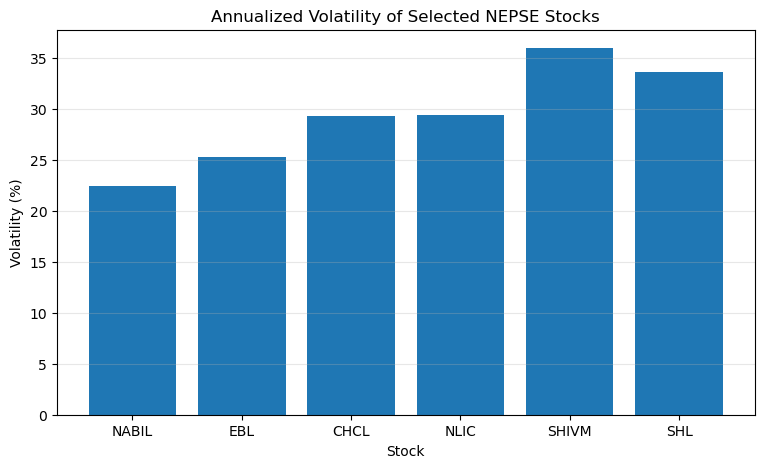

In [97]:
plt.figure(figsize=(9, 5))

plt.bar(
    summary_df["Symbol"],
    summary_df["Annualized Volatility (%)"]
)

plt.title(
    "Annualized Volatility of Selected NEPSE Stocks"
)

plt.xlabel("Stock")
plt.ylabel("Volatility (%)")

plt.grid(
    axis="y",
    alpha=0.3
)

plt.show()

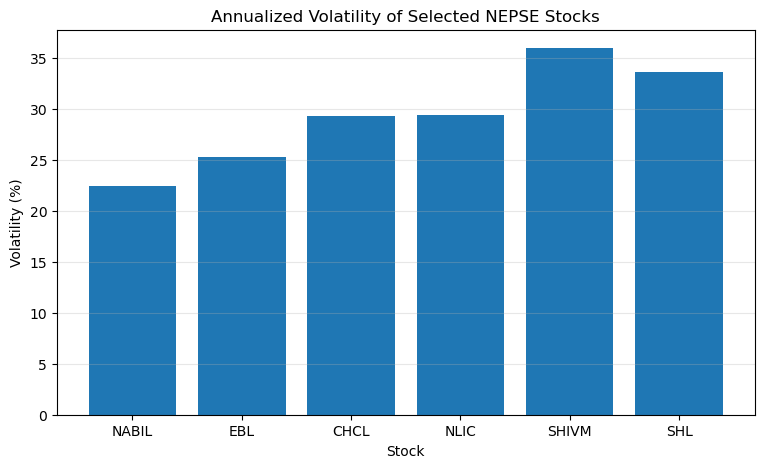

In [99]:
plt.figure(figsize=(9, 5))

plt.bar(
    summary_df["Symbol"],
    summary_df["Annualized Volatility (%)"]
)

plt.title(
    "Annualized Volatility of Selected NEPSE Stocks"
)

plt.xlabel("Stock")
plt.ylabel("Volatility (%)")

plt.grid(
    axis="y",
    alpha=0.3
)

plt.savefig(
    "charts/volatility_comparison.png",
    bbox_inches="tight"
)

plt.show()

In [101]:
returns_table = all_stocks.pivot(
    index="published_date",
    columns="symbol",
    values="daily_return"
)

returns_table.head()

symbol,CHCL,EBL,NABIL,NLIC,SHIVM,SHL
published_date,,,,,,
2022-01-02,NaN,NaN,NaN,NaN,NaN,NaN
2022-01-03,0.008386,0.047263,-0.006119,0.009217,-0.000655,0.014423
2022-01-04,0.049896,0.071615,-0.015831,0.007828,-0.003279,0.014218
2022-01-05,-0.029703,-0.029268,-0.006345,0.014887,0.001974,-0.017290
2022-01-06,0.016327,0.028476,0.001889,0.007015,-0.005253,0.031859


In [103]:
correlation_matrix = returns_table.corr()
correlation_matrix

symbol,CHCL,EBL,NABIL,NLIC,SHIVM,SHL
symbol,,,,,,
CHCL,1.000000,0.457415,0.440158,0.505034,0.514176,0.453092
EBL,0.457415,1.000000,0.502478,0.489634,0.451823,0.375867
NABIL,0.440158,0.502478,1.000000,0.547190,0.460449,0.352026
NLIC,0.505034,0.489634,0.547190,1.000000,0.632458,0.495871
SHIVM,0.514176,0.451823,0.460449,0.632458,1.000000,0.483792
SHL,0.453092,0.375867,0.352026,0.495871,0.483792,1.000000


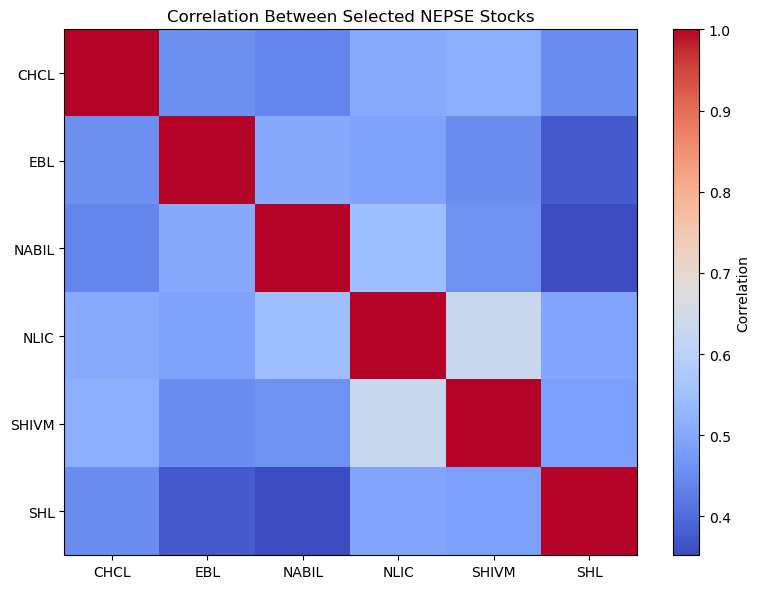

In [105]:
plt.figure(figsize=(8, 6))

plt.imshow(
    correlation_matrix,
    cmap="coolwarm",
    aspect="auto"
)

plt.colorbar(label="Correlation")

plt.xticks(
    range(len(correlation_matrix.columns)),
    correlation_matrix.columns
)

plt.yticks(
    range(len(correlation_matrix.index)),
    correlation_matrix.index
)

plt.title(
    "Correlation Between Selected NEPSE Stocks"
)

plt.tight_layout()
plt.show()

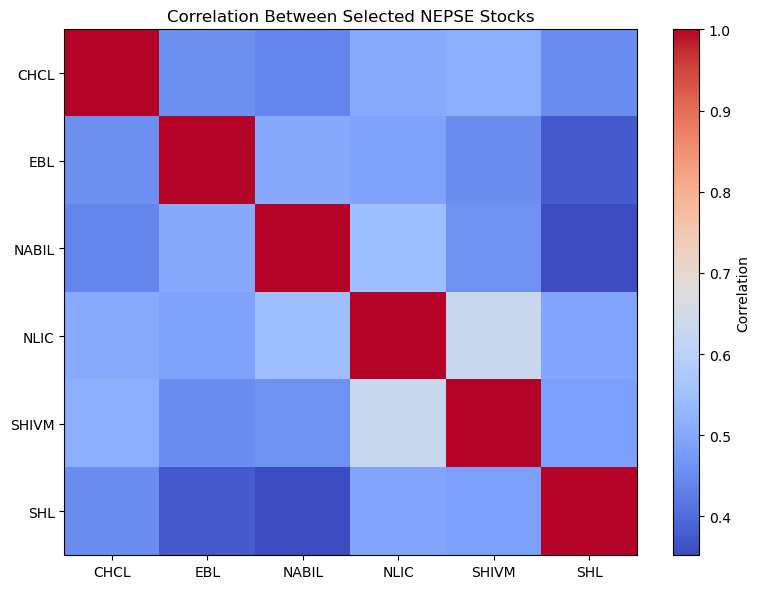

In [107]:
plt.figure(figsize=(8, 6))

plt.imshow(
    correlation_matrix,
    cmap="coolwarm",
    aspect="auto"
)

plt.colorbar(label="Correlation")

plt.xticks(
    range(len(correlation_matrix.columns)),
    correlation_matrix.columns
)

plt.yticks(
    range(len(correlation_matrix.index)),
    correlation_matrix.index
)

plt.title(
    "Correlation Between Selected NEPSE Stocks"
)

plt.tight_layout()

plt.savefig(
    "charts/correlation_matrix.png",
    bbox_inches="tight"
)

plt.show()

In [109]:
correlation_matrix.to_csv(
    "data/correlation_matrix.csv"
)

In [111]:
initial_investment = 100000

In [113]:
number_of_stocks = 6

investment_per_stock = (
    initial_investment / number_of_stocks
)

print(
    "Investment per stock:",
    round(investment_per_stock, 2)
)

Investment per stock: 16666.67


In [115]:
portfolio_daily_return = (
    returns_table.mean(
        axis=1,
        skipna=True
    )
)

In [117]:
portfolio_daily_return.head()

published_date
2022-01-02         NaN
2022-01-03    0.012086
2022-01-04    0.020741
2022-01-05   -0.010958
2022-01-06    0.013385
dtype: float64

In [119]:
portfolio_value = (
    initial_investment
    *
    (
        1 + portfolio_daily_return.fillna(0)
    ).cumprod()
)

In [121]:
portfolio_value.head()

published_date
2022-01-02    100000.000000
2022-01-03    101208.566594
2022-01-04    103307.755215
2022-01-05    102175.751571
2022-01-06    103543.419403
dtype: float64

In [123]:
portfolio_value.tail()

published_date
2026-09-24    87132.191738
2026-09-28    86752.209467
2026-09-29    86335.559698
2026-09-30    85049.585283
2026-10-01    84738.150989
dtype: float64

In [125]:
final_portfolio_value = (
    portfolio_value.iloc[-1]
)

print(
    "Final Portfolio Value:",
    round(final_portfolio_value, 2)
)

Final Portfolio Value: 84738.15


In [127]:
portfolio_change = (
    (
        final_portfolio_value
        / initial_investment
    )
    - 1
) * 100

In [129]:
print(
    "Portfolio Change:",
    round(portfolio_change, 2),
    "%"
)

Portfolio Change: -15.26 %


In [131]:
portfolio_volatility = (
    portfolio_daily_return.std()
    * np.sqrt(252)
    * 100
)

In [133]:
print(
    "Portfolio Annualized Volatility:",
    round(portfolio_volatility, 2),
    "%"
)

Portfolio Annualized Volatility: 22.12 %


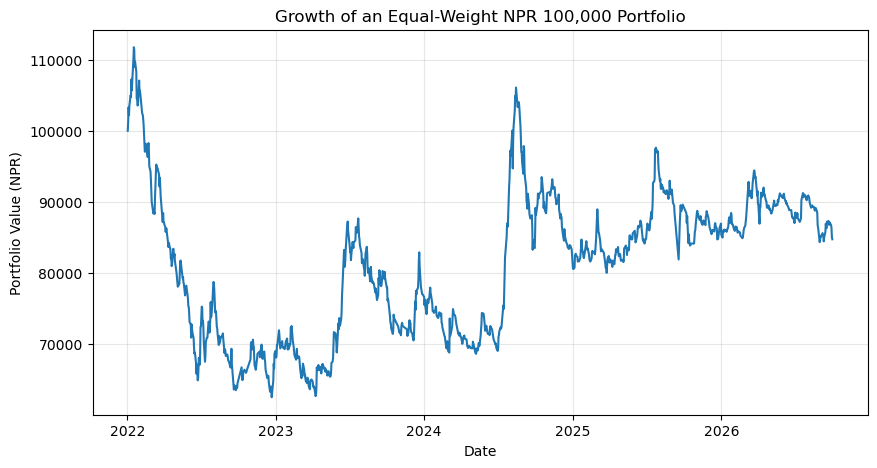

In [135]:
plt.figure(figsize=(10, 5))

plt.plot(
    portfolio_value.index,
    portfolio_value.values
)

plt.title(
    "Growth of an Equal-Weight NPR 100,000 Portfolio"
)

plt.xlabel("Date")
plt.ylabel("Portfolio Value (NPR)")

plt.grid(
    True,
    alpha=0.3
)

plt.show()

In [137]:
comparison_volatility = summary_df[
    [
        "Symbol",
        "Annualized Volatility (%)"
    ]
].copy()

In [139]:
portfolio_row = pd.DataFrame(
    {
        "Symbol": ["Portfolio"],
        "Annualized Volatility (%)": [
            portfolio_volatility
        ]
    }
)

In [141]:
comparison_volatility = pd.concat(
    [
        comparison_volatility,
        portfolio_row
    ],
    ignore_index=True
)

comparison_volatility

,Symbol,Annualized Volatility (%)
0,NABIL,22.400000
1,EBL,25.300000
2,CHCL,29.280000
3,NLIC,29.430000
4,SHIVM,35.950000
5,SHL,33.580000
6,Portfolio,22.123759


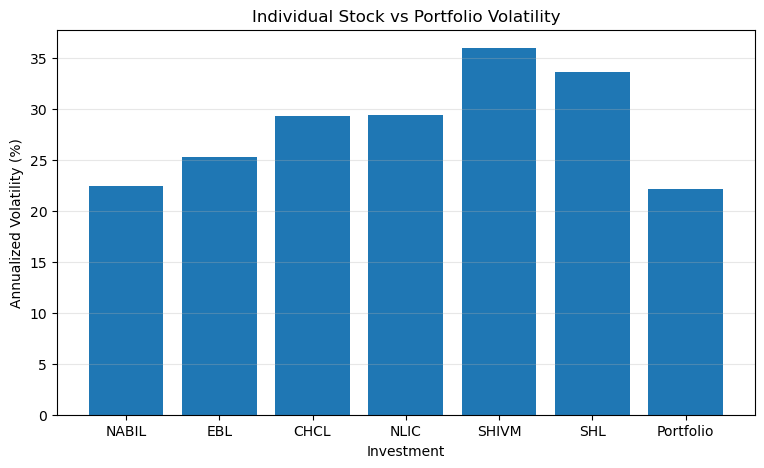

In [143]:
plt.figure(figsize=(9, 5))

plt.bar(
    comparison_volatility["Symbol"],
    comparison_volatility[
        "Annualized Volatility (%)"
    ]
)

plt.title(
    "Individual Stock vs Portfolio Volatility"
)

plt.xlabel("Investment")
plt.ylabel("Annualized Volatility (%)")

plt.grid(
    axis="y",
    alpha=0.3
)

plt.show()

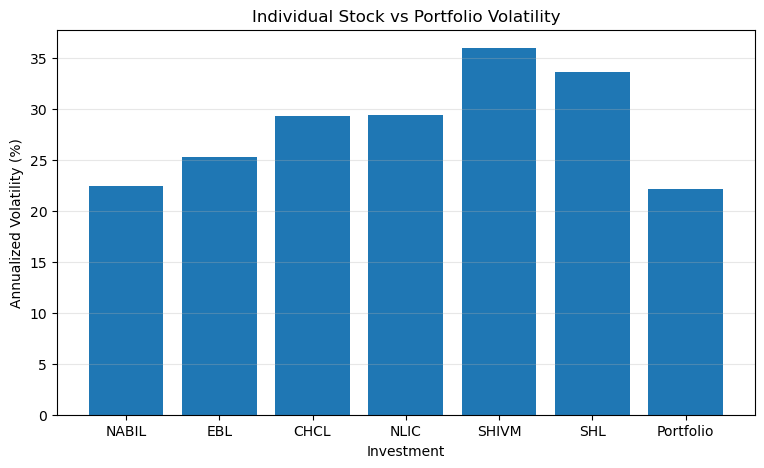

In [145]:
plt.figure(figsize=(9, 5))

plt.bar(
    comparison_volatility["Symbol"],
    comparison_volatility[
        "Annualized Volatility (%)"
    ]
)

plt.title(
    "Individual Stock vs Portfolio Volatility"
)

plt.xlabel("Investment")
plt.ylabel("Annualized Volatility (%)")

plt.grid(
    axis="y",
    alpha=0.3
)

plt.savefig(
    "charts/portfolio_vs_stock_volatility.png",
    bbox_inches="tight"
)

plt.show()

In [147]:
nepse_url = (
    "https://raw.githubusercontent.com/"
    "binayabaral/nepal-market-data/"
    "main/data/nepse/NEPSE_INDEX.csv"
)
nepse = pd.read_csv(nepse_url)
nepse.head()

,published_date,open,high,low,close,per_change,traded_quantity,traded_amount,status
0,1997-07-20,173.26,173.26,173.26,173.26,0.0,NaN,0.0,A
1,1997-07-21,173.25,173.25,173.25,173.25,0.0,NaN,0.0,A
2,1997-07-22,173.03,173.03,173.03,173.03,0.0,NaN,0.0,A
3,1997-07-23,172.68,173.03,173.03,173.03,0.0,NaN,0.0,A
4,1997-07-24,172.66,172.66,172.66,172.66,0.0,NaN,0.0,A


In [149]:
nepse.columns

Index(['published_date', 'open', 'high', 'low', 'close', 'per_change',
       'traded_quantity', 'traded_amount', 'status'],
      dtype='object')

In [151]:
nepse.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6709 entries, 0 to 6708
Data columns (total 9 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   published_date   6709 non-null   object 
 1   open             6709 non-null   float64
 2   high             6709 non-null   float64
 3   low              6709 non-null   float64
 4   close            6709 non-null   float64
 5   per_change       6709 non-null   float64
 6   traded_quantity  0 non-null      float64
 7   traded_amount    6709 non-null   float64
 8   status           6709 non-null   object 
dtypes: float64(7), object(2)
memory usage: 471.9+ KB


In [153]:
nepse["published_date"] = pd.to_datetime(
    nepse["published_date"]
)

In [155]:
nepse.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6709 entries, 0 to 6708
Data columns (total 9 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   published_date   6709 non-null   datetime64[ns]
 1   open             6709 non-null   float64       
 2   high             6709 non-null   float64       
 3   low              6709 non-null   float64       
 4   close            6709 non-null   float64       
 5   per_change       6709 non-null   float64       
 6   traded_quantity  0 non-null      float64       
 7   traded_amount    6709 non-null   float64       
 8   status           6709 non-null   object        
dtypes: datetime64[ns](1), float64(7), object(1)
memory usage: 471.9+ KB


In [157]:
nepse = nepse[
    (nepse["published_date"] >= "2022-01-01") &
    (nepse["published_date"] <= "2026-12-31")
].copy()

In [159]:
print("First date:", nepse["published_date"].min())
print("Last date:", nepse["published_date"].max())

First date: 2022-01-02 00:00:00
Last date: 2026-10-01 00:00:00


In [161]:
nepse = nepse.sort_values(
    "published_date"
).reset_index(drop=True)

In [163]:
nepse["daily_return"] = (
    nepse["close"].pct_change()
)

In [165]:
nepse[
    [
        "published_date",
        "close",
        "daily_return"
    ]
].head(10)

,published_date,close,daily_return
0,2022-01-02,2584.91,NaN
1,2022-01-03,2616.94,0.012391
2,2022-01-04,2679.95,0.024078
3,2022-01-05,2649.18,-0.011482
4,2022-01-06,2692.47,0.016341
5,2022-01-09,2765.51,0.027128
6,2022-01-10,2784.95,0.007029
7,2022-01-11,2834.13,0.017659
8,2022-01-12,2803.62,-0.010765
9,2022-01-13,2857.75,0.019307


In [167]:
nepse_growth = (
    1
    +
    nepse.set_index(
        "published_date"
    )["daily_return"].fillna(0)
).cumprod()

In [169]:
nepse_growth.head()

published_date
2022-01-02    1.000000
2022-01-03    1.012391
2022-01-04    1.036767
2022-01-05    1.024864
2022-01-06    1.041611
Name: daily_return, dtype: float64

In [171]:
portfolio_growth = (
    portfolio_value
    / initial_investment
)

In [173]:
portfolio_growth.head()

published_date
2022-01-02    1.000000
2022-01-03    1.012086
2022-01-04    1.033078
2022-01-05    1.021758
2022-01-06    1.035434
dtype: float64

In [175]:
benchmark_comparison = pd.concat(
    [
        portfolio_growth.rename("Portfolio"),
        nepse_growth.rename("NEPSE Index")
    ],
    axis=1
)

In [177]:
benchmark_comparison.head()

,Portfolio,NEPSE Index
published_date,,
2022-01-02,1.000000,1.000000
2022-01-03,1.012086,1.012391
2022-01-04,1.033078,1.036767
2022-01-05,1.021758,1.024864
2022-01-06,1.035434,1.041611


In [181]:
benchmark_comparison = (
    benchmark_comparison.dropna()
)

In [183]:
benchmark_comparison.head()

,Portfolio,NEPSE Index
published_date,,
2022-01-02,1.000000,1.000000
2022-01-03,1.012086,1.012391
2022-01-04,1.033078,1.036767
2022-01-05,1.021758,1.024864
2022-01-06,1.035434,1.041611


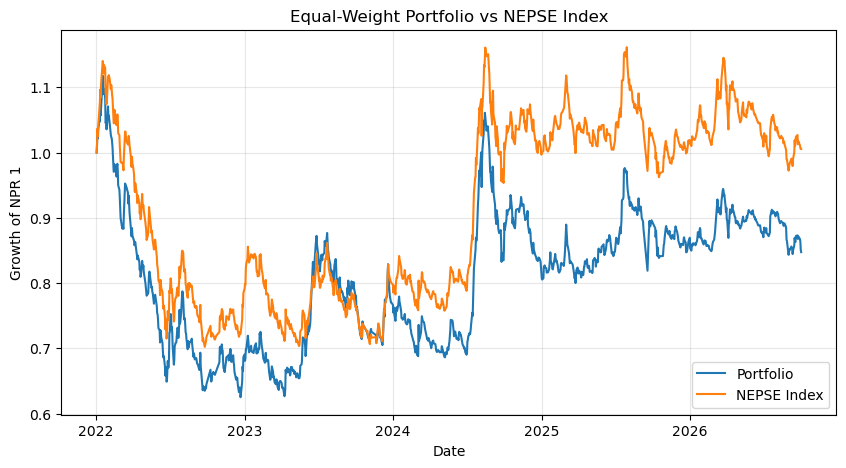

In [185]:
plt.figure(figsize=(10, 5))

plt.plot(
    benchmark_comparison.index,
    benchmark_comparison["Portfolio"],
    label="Portfolio"
)

plt.plot(
    benchmark_comparison.index,
    benchmark_comparison["NEPSE Index"],
    label="NEPSE Index"
)

plt.title(
    "Equal-Weight Portfolio vs NEPSE Index"
)

plt.xlabel("Date")
plt.ylabel("Growth of NPR 1")

plt.legend()

plt.grid(
    True,
    alpha=0.3
)

plt.show()

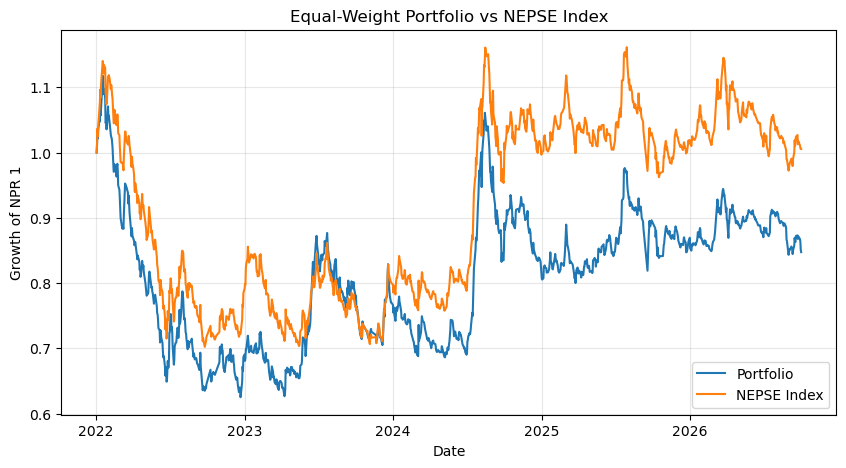

In [187]:
plt.figure(figsize=(10, 5))

plt.plot(
    benchmark_comparison.index,
    benchmark_comparison["Portfolio"],
    label="Portfolio"
)

plt.plot(
    benchmark_comparison.index,
    benchmark_comparison["NEPSE Index"],
    label="NEPSE Index"
)

plt.title(
    "Equal-Weight Portfolio vs NEPSE Index"
)

plt.xlabel("Date")
plt.ylabel("Growth of NPR 1")

plt.legend()

plt.grid(
    True,
    alpha=0.3
)

plt.savefig(
    "charts/portfolio_vs_nepse.png",
    bbox_inches="tight"
)

plt.show()

In [189]:
portfolio_final_growth = (
    benchmark_comparison["Portfolio"]
    .iloc[-1]
)

nepse_final_growth = (
    benchmark_comparison["NEPSE Index"]
    .iloc[-1]
)

In [191]:
print(
    "Portfolio Final Growth:",
    round(portfolio_final_growth, 3)
)

print(
    "NEPSE Final Growth:",
    round(nepse_final_growth, 3)
)

Portfolio Final Growth: 0.847
NEPSE Final Growth: 1.006


In [193]:
portfolio_benchmark_change = (
    portfolio_final_growth - 1
) * 100

nepse_change = (
    nepse_final_growth - 1
) * 100

In [195]:
print(
    "Portfolio Change:",
    round(portfolio_benchmark_change, 2),
    "%"
)

print(
    "NEPSE Index Change:",
    round(nepse_change, 2),
    "%"
)

Portfolio Change: -15.26 %
NEPSE Index Change: 0.55 %


In [197]:
price_table = all_stocks.pivot(
    index="published_date",
    columns="symbol",
    values="close"
)

price_table.head()

symbol,CHCL,EBL,NABIL,NLIC,SHIVM,SHL
published_date,,,,,,
2022-01-02,477.0,548.0,1144.0,1519.0,1526.0,208.0
2022-01-03,481.0,573.9,1137.0,1533.0,1525.0,211.0
2022-01-04,505.0,615.0,1119.0,1545.0,1520.0,214.0
2022-01-05,490.0,597.0,1111.9,1568.0,1523.0,210.3
2022-01-06,498.0,614.0,1114.0,1579.0,1515.0,217.0


In [199]:
initial_investment = 100000
number_of_stocks = 6

In [201]:
investment_per_stock = (
    initial_investment / number_of_stocks
)

investment_per_stock

16666.666666666668

In [203]:
initial_prices = price_table.iloc[0]

initial_prices

symbol
CHCL      477.0
EBL       548.0
NABIL    1144.0
NLIC     1519.0
SHIVM    1526.0
SHL       208.0
Name: 2022-01-02 00:00:00, dtype: float64

In [205]:
shares_purchased = (
    investment_per_stock
    / initial_prices
)

shares_purchased

symbol
CHCL     34.940601
EBL      30.413625
NABIL    14.568765
NLIC     10.972131
SHIVM    10.921800
SHL      80.128205
Name: 2022-01-02 00:00:00, dtype: float64

In [207]:
stock_values = (
    price_table
    * shares_purchased
)

stock_values.head()

symbol,CHCL,EBL,NABIL,NLIC,SHIVM,SHL
published_date,,,,,,
2022-01-02,16666.666667,16666.666667,16666.666667,16666.666667,16666.666667,16666.666667
2022-01-03,16806.429071,17454.379562,16564.685315,16820.276498,16655.744867,16907.051282
2022-01-04,17645.003494,18704.379562,16302.447552,16951.942067,16601.135867,17147.435897
2022-01-05,17120.894479,18156.934307,16199.009324,17204.301075,16633.901267,16850.961538
2022-01-06,17400.419287,18673.965937,16229.603730,17324.994514,16546.526868,17387.820513


In [209]:
buy_hold_portfolio = (
    stock_values.sum(axis=1)
)

In [211]:
buy_hold_portfolio.head()

published_date
2022-01-02    100000.000000
2022-01-03    101208.566594
2022-01-04    103352.344440
2022-01-05    102166.001991
2022-01-06    103563.330848
dtype: float64

In [213]:
buy_hold_portfolio.tail()

published_date
2026-09-24    99146.932103
2026-09-28    98816.685898
2026-09-29    98350.585823
2026-09-30    97341.566248
2026-10-01    97130.167281
dtype: float64

In [215]:
buy_hold_final_value = (
    buy_hold_portfolio.iloc[-1]
)

buy_hold_change = (
    (
        buy_hold_final_value
        / initial_investment
    )
    - 1
) * 100

In [217]:
print(
    "Buy-and-Hold Final Value:",
    round(buy_hold_final_value, 2)
)

print(
    "Buy-and-Hold Portfolio Change:",
    round(buy_hold_change, 2),
    "%"
)

Buy-and-Hold Final Value: 97130.17
Buy-and-Hold Portfolio Change: -2.87 %


In [219]:
buy_hold_daily_return = (
    buy_hold_portfolio.pct_change()
)

In [221]:
buy_hold_volatility = (
    buy_hold_daily_return.std()
    * np.sqrt(252)
    * 100
)

print(
    "Buy-and-Hold Annualized Volatility:",
    round(buy_hold_volatility, 2),
    "%"
)

Buy-and-Hold Annualized Volatility: 23.02 %


In [223]:
buy_hold_growth = (
    buy_hold_portfolio
    / initial_investment
)

In [225]:
final_comparison = pd.concat(
    [
        buy_hold_growth.rename("Portfolio"),
        nepse_growth.rename("NEPSE Index")
    ],
    axis=1
).dropna()

In [227]:
final_comparison.head()

,Portfolio,NEPSE Index
published_date,,
2022-01-02,1.000000,1.000000
2022-01-03,1.012086,1.012391
2022-01-04,1.033523,1.036767
2022-01-05,1.021660,1.024864
2022-01-06,1.035633,1.041611


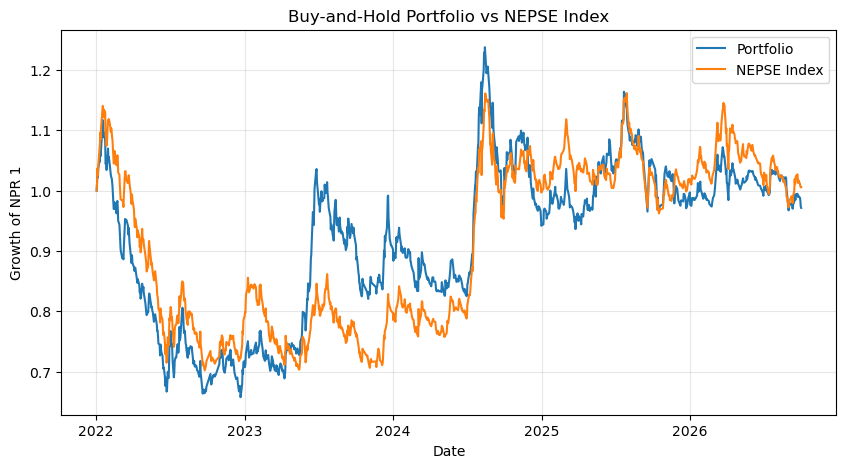

In [229]:
plt.figure(figsize=(10, 5))

plt.plot(
    final_comparison.index,
    final_comparison["Portfolio"],
    label="Portfolio"
)

plt.plot(
    final_comparison.index,
    final_comparison["NEPSE Index"],
    label="NEPSE Index"
)

plt.title(
    "Buy-and-Hold Portfolio vs NEPSE Index"
)

plt.xlabel("Date")
plt.ylabel("Growth of NPR 1")

plt.legend()
plt.grid(True, alpha=0.3)

plt.show()

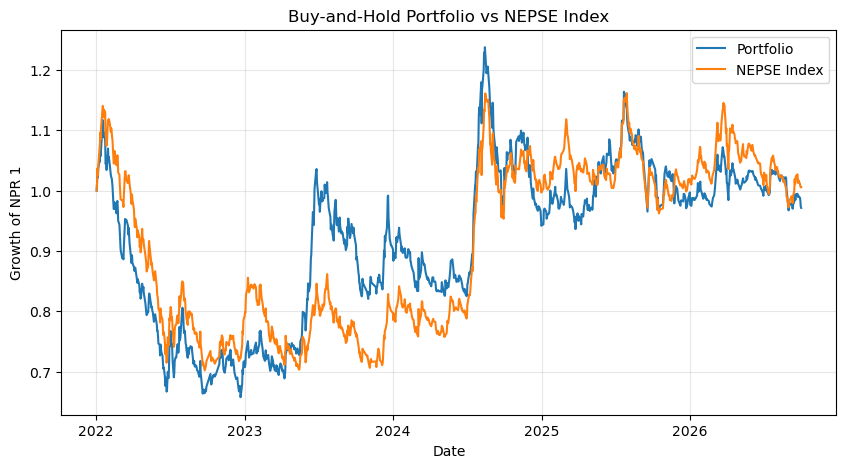

In [231]:
plt.figure(figsize=(10, 5))

plt.plot(
    final_comparison.index,
    final_comparison["Portfolio"],
    label="Portfolio"
)

plt.plot(
    final_comparison.index,
    final_comparison["NEPSE Index"],
    label="NEPSE Index"
)

plt.title(
    "Buy-and-Hold Portfolio vs NEPSE Index"
)

plt.xlabel("Date")
plt.ylabel("Growth of NPR 1")

plt.legend()
plt.grid(True, alpha=0.3)

plt.savefig(
    "charts/buy_hold_vs_nepse.png",
    bbox_inches="tight"
)

plt.show()

In [233]:
portfolio_final_growth = (
    final_comparison["Portfolio"].iloc[-1]
)

nepse_final_growth = (
    final_comparison["NEPSE Index"].iloc[-1]
)

print(
    "Portfolio Final Growth:",
    round(portfolio_final_growth, 3)
)

print(
    "NEPSE Final Growth:",
    round(nepse_final_growth, 3)
)

Portfolio Final Growth: 0.971
NEPSE Final Growth: 1.006


In [235]:
portfolio_change_final = (
    portfolio_final_growth - 1
) * 100

nepse_change_final = (
    nepse_final_growth - 1
) * 100

print(
    "Portfolio Change:",
    round(portfolio_change_final, 2),
    "%"
)

print(
    "NEPSE Index Change:",
    round(nepse_change_final, 2),
    "%"
)

Portfolio Change: -2.87 %
NEPSE Index Change: 0.55 %
